#  Practice 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

data = {
    "age"   : [22,25,47,52,46,56,55,60,62,61,
               18,28,27,29,49,55,25,58,19,40],
    "bought": [0,0,1,1,1,1,0,1,1,1,
               0,0,0,0,1,1,0,1,0,1]
    # 0 = didn't buy, 1 = bought product
}
df= pd.DataFrame(data)

X= df[["age"]]
y=df["bought"]


# split
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(
        C=1.0, # regularization strength
        max_iter=100,# maximum iterations
    random_state=42    ) # reproducibility

model.fit(X_train,y_train)

y_Pred= model.predict(X_test)
# predict probability
y_prob= model.predict_proba(X_test)


print("predicted class:",y_Pred)
print("Predicted probability:", y_prob)
print("Actual               :", list(y_test))





new_age =[[35]]  # 35 year
print("Pridicted for age 35: ", model.predict(new_age))
print("Probability for age 35:", 
       model.predict_proba(new_age))


predicted class: [0 1 1 0]
Predicted probability: [[0.95909232 0.04090768]
 [0.03977708 0.96022292]
 [0.06564086 0.93435914]
 [0.93254506 0.06745494]]
Actual               : [0, 1, 1, 0]
Pridicted for age 35:  [0]
Probability for age 35: [[0.70386078 0.29613922]]


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [15]:


# accuracy
print("accuracy :", accuracy_score(y_Pred,y_test))
# confusion matrix
cm=confusion_matrix(y_test,y_Pred)
print("confusion matrix: \n",cm)
# fill report 
print(classification_report(y_test, y_Pred))

accuracy : 1.0
confusion matrix: 
 [[2 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


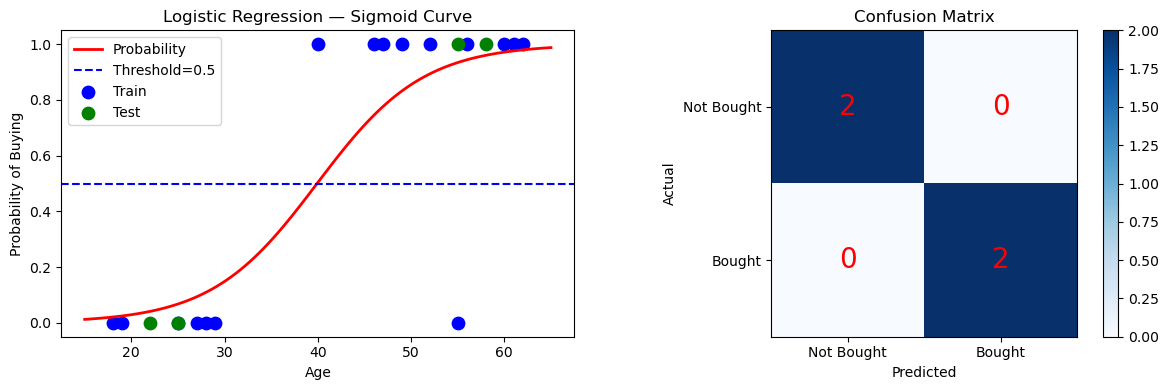

In [20]:
# plots
plt.figure(figsize=(12, 4))

# Plot 1 — Sigmoid Curve
plt.subplot(1, 2, 1)
x_range = np.linspace(15, 65, 100).reshape(-1, 1)  # ✅ fixed!
probabilities = model.predict_proba(x_range)[:, 1]

plt.plot(x_range, probabilities,
         color="red", linewidth=2, label="Probability")
plt.axhline(y=0.5, color="blue",
            linestyle="--", label="Threshold=0.5")
plt.scatter(X_train, y_train,
            color="blue", label="Train", s=80)
plt.scatter(X_test, y_test,
            color="green", label="Test", s=80)
plt.xlabel("Age")
plt.ylabel("Probability of Buying")
plt.title("Logistic Regression — Sigmoid Curve")
plt.legend()

# Plot 2 — Confusion Matrix
plt.subplot(1, 2, 2)
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Bought","Bought"])
plt.yticks([0,1], ["Not Bought","Bought"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                ha="center", va="center",
                color="red", fontsize=20)
plt.tight_layout()
plt.show()